In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Show plots inline (Jupyter)
%matplotlib inline

sm_path = "../data/smartmeter_15min_all_from_devices_20251101_20251103.parquet"


In [83]:
df_sm = pd.read_parquet(sm_path)


# List of substations / dnr_str values you want to exclude
exclude_dnr = [6, 1133,1508,1160, 1159, 841, 1329, 1340,1554,1365,1418,604,29,1390,1021,1357,1345,707]  # add more here later

df_sm = df_sm[~df_sm["substation_id"].isin(exclude_dnr)].copy()

# Make sure timestamp is datetime and sorted
df_sm["ts"] = pd.to_datetime(df_sm["ts"])
df_sm = df_sm.sort_values(["substation_id", "ts"])



df_sm.head()


,substation_id,ts,I_a,I_b,I_c,I_total,n_mps,per_completed
386,55,2025-11-01 12:00:00,837.850,725.905,667.885,2231.64,158,0.629921
387,55,2025-11-01 12:15:00,847.730,728.890,661.020,2237.64,158,0.629921
388,55,2025-11-01 12:30:00,851.235,726.645,655.140,2233.02,158,0.629921
389,55,2025-11-01 12:45:00,853.000,721.410,651.670,2226.08,158,0.629921
390,55,2025-11-01 13:00:00,836.880,715.685,642.245,2194.81,158,0.629921


In [84]:
print("Shape (rows, cols):", df_sm.shape)
print("\nData types:")
print(df_sm.dtypes)

print("\nTime range:")
print("  From:", df_sm["ts"].min())
print("  To  :", df_sm["ts"].max())

print("\nNumber of unique substations:", df_sm["substation_id"].nunique())
print("List of substations (first 20):", df_sm["substation_id"].unique()[:20])

print("\nOverall current stats (A):")
print(df_sm[["I_a", "I_b", "I_c", "I_total"]].describe())

print("\nSmart meter completeness:")
print("  n_mps min/max:", df_sm["n_mps"].min(), "/", df_sm["n_mps"].max())
print("  per_completed describe:")
print(df_sm["per_completed"].describe())


Shape (rows, cols): (13124, 8)

Data types:
substation_id             int32
ts               datetime64[ns]
I_a                     float64
I_b                     float64
I_c                     float64
I_total                 float64
n_mps                     int64
per_completed           float64
dtype: object

Time range:
  From: 2025-11-01 12:00:00
  To  : 2025-11-03 12:00:00

Number of unique substations: 68
List of substations (first 20): [ 55  74  76 173 176 202 246 263 303 383 403 411 537 579 607 613 615 662
 670 688]

Overall current stats (A):
                I_a           I_b           I_c       I_total
count  13124.000000  13124.000000  13124.000000  13124.000000
mean     347.617467    180.215376    171.873783    699.706626
std      286.936122    201.973691    197.735787    621.208406
min        3.000000      2.610000      1.850000     14.000000
25%      118.817500     62.383750     56.000000    253.340000
50%      293.047500    114.432500    103.772500    536.820000
75%   

In [85]:
substation_stats = (
    df_sm
    .groupby("substation_id")
    .agg(
        mean_I_a=("I_a", "mean"),
        mean_I_b=("I_b", "mean"),
        mean_I_c=("I_c", "mean"),
        mean_I_total=("I_total", "mean"),
        max_I_total=("I_total", "max"),
        mean_per_completed=("per_completed", "mean"),
        n_samples=("ts", "count"),
    )
    .reset_index()
)

substation_stats.head()


,substation_id,mean_I_a,mean_I_b,mean_I_c,mean_I_total,max_I_total,mean_per_completed,n_samples
0,55,645.668342,548.009482,487.315207,1680.993031,3936.27,0.629921,193
1,74,305.133187,271.952694,260.463782,837.549663,1257.43,0.461538,193
2,76,605.749741,505.928342,440.635622,1552.313705,2079.59,0.386441,193
3,173,332.174922,263.213808,248.129067,843.517798,1174.81,0.471429,193
4,176,429.306451,369.921606,359.370104,1158.598161,1685.89,0.571429,193


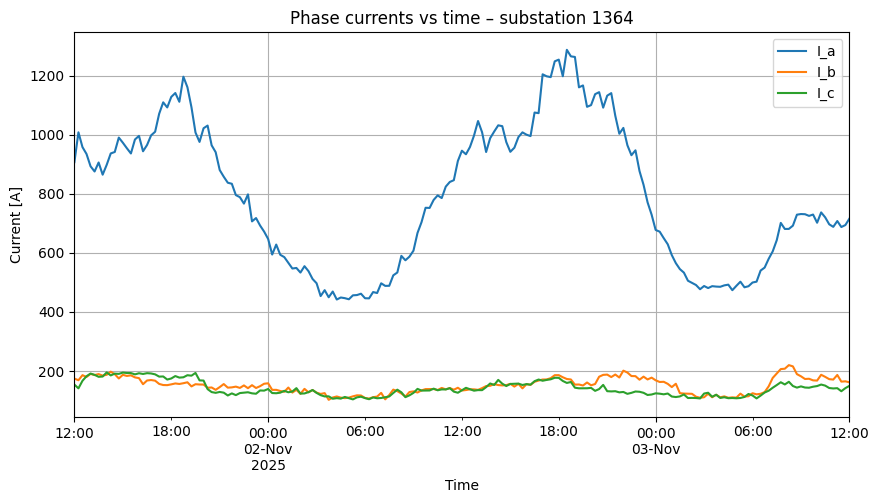

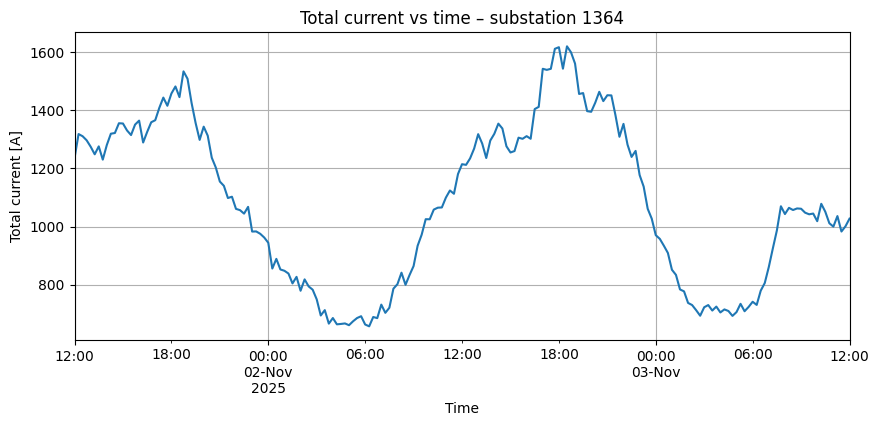

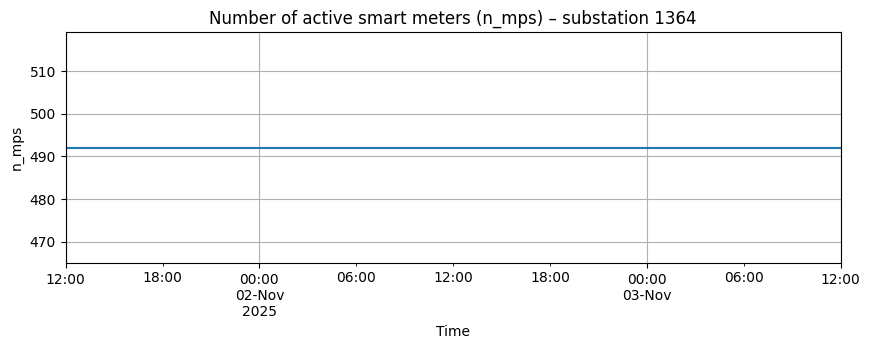

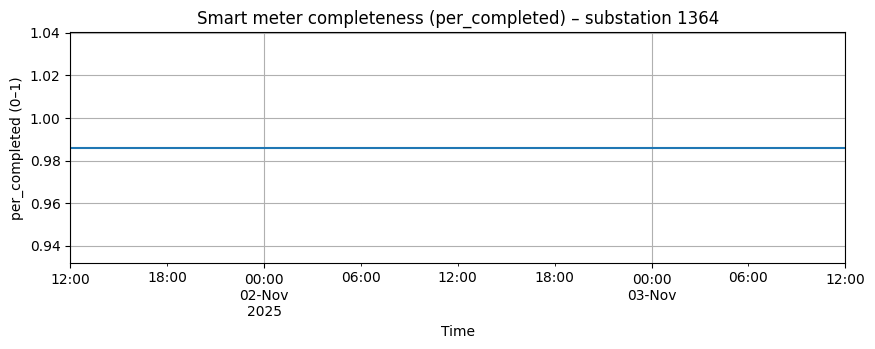

avg total current: 1082.6062953367875


In [102]:
sub_id = 1364  # <-- change this

df_one = df_sm[df_sm["substation_id"] == sub_id].copy()
df_one = df_one.sort_values("ts").set_index("ts")

# ---- Phase currents ----
df_one[["I_a", "I_b", "I_c"]].plot(figsize=(10, 5))
plt.title(f"Phase currents vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Current [A]")
plt.grid(True)
plt.show()

# ---- Total current ----
df_one["I_total"].plot(figsize=(10, 4))
plt.title(f"Total current vs time – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("Total current [A]")
plt.grid(True)
plt.show()

# ---- n_mps ----
df_one["n_mps"].plot(figsize=(10, 3))
plt.title(f"Number of active smart meters (n_mps) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("n_mps")
plt.grid(True)
plt.show()

# ---- per_completed ----
df_one["per_completed"].plot(figsize=(10, 3))
plt.title(f"Smart meter completeness (per_completed) – substation {sub_id}")
plt.xlabel("Time")
plt.ylabel("per_completed (0–1)")
plt.grid(True)
plt.show()

print("avg total current:", df_one["I_total"].mean())


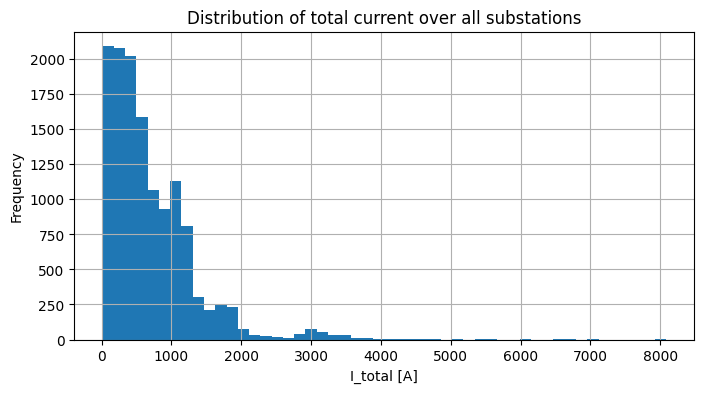

In [87]:
df_sm["I_total"].plot(kind="hist", bins=50, figsize=(8, 4))
plt.title("Distribution of total current over all substations")
plt.xlabel("I_total [A]")
plt.grid(True)
plt.show()


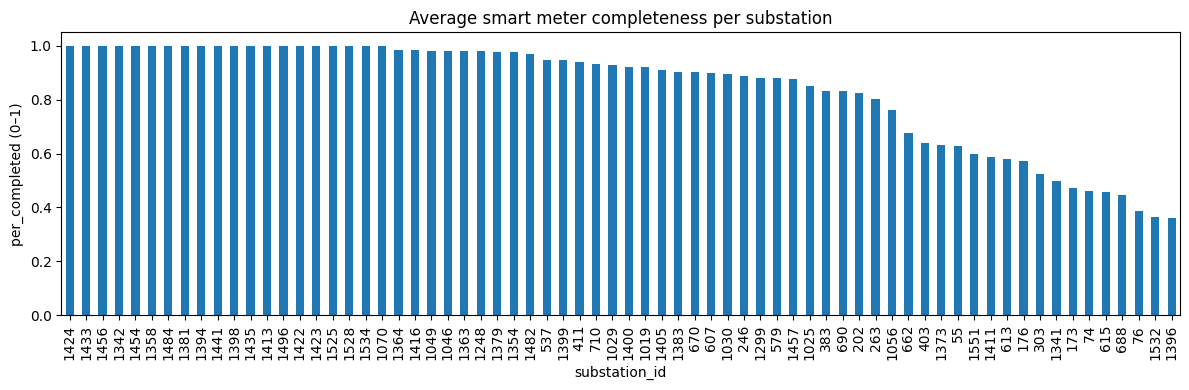

In [88]:
avg_comp = (
    df_sm.groupby("substation_id")["per_completed"]
    .mean()
    .sort_values(ascending=False)
)

avg_comp.plot(kind="bar", figsize=(12, 4))
plt.title("Average smart meter completeness per substation")
plt.ylabel("per_completed (0–1)")
plt.xlabel("substation_id")
plt.tight_layout()
plt.show()


Cutoff = 0.90: keeping 39 of 68 substations


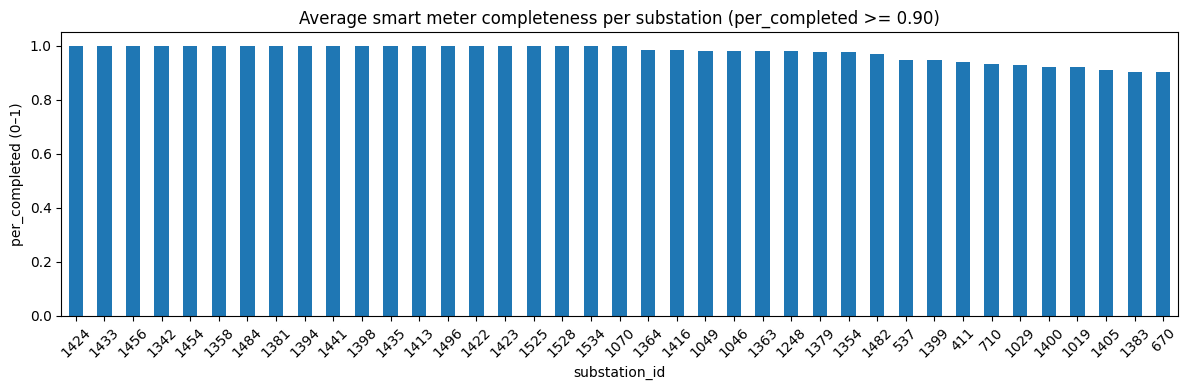

In [90]:
# Set cutoff threshold (0.0 - 1.0). Substations with avg per_completed < cutoff will be excluded.
cutoff = 0.9

filtered = avg_comp[avg_comp >= cutoff]

print(f"Cutoff = {cutoff:.2f}: keeping {len(filtered)} of {len(avg_comp)} substations")
if filtered.empty:
    print("No substations meet the cutoff. Lower the threshold.")
else:
    ax = filtered.plot(kind="bar", figsize=(12, 4))
    ax.set_title(f"Average smart meter completeness per substation (per_completed >= {cutoff:.2f})")
    ax.set_ylabel("per_completed (0–1)")
    ax.set_xlabel("substation_id")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()